# Experiment 6 - Extended Period Simulation (EPS)

## Objective

Evaluate the hydraulic behaviour of the benchmark network over a complete operating cycle using a 24-hour demand pattern.

Unlike the previous steady-state experiments, this study evaluates how hydraulic conditions change throughout the day.

---

## Why EPS?

Real water distribution systems never operate at constant demand.

Customer water consumption varies throughout the day due to residential, commercial and industrial activities.

Extended Period Simulation (EPS) allows EPANET to simulate these varying demand conditions over time.

---

## Parameters Studied

- Pressure
- Flow
- Velocity
- Headloss

---

## Expected Behaviour

- Morning and evening demand peaks increase flow.
- Higher flow increases velocity.
- Higher flow increases headloss.
- Pressure decreases during peak demand.
- Pressure recovers during low-demand periods.

---

## Engineering Importance

EPS is widely used for

- Pump scheduling
- Operational planning
- Digital Twin development
- Leak monitoring
- SCADA-based hydraulic analysis

In [1]:
import wntr
import pandas as pd
import matplotlib.pyplot as plt

wn = wntr.network.WaterNetworkModel(
    "production_benchmark_pump.inp"
)

In [2]:
pattern = [

    0.50,
    0.45,
    0.40,
    0.40,
    0.50,
    0.70,

    1.00,
    1.25,
    1.40,
    1.20,
    1.05,
    0.95,

    0.90,
    0.85,
    0.80,
    0.90,
    1.05,
    1.25,

    1.40,
    1.30,
    1.10,
    0.90,
    0.70,
    0.55

]

wn.add_pattern(
    "DailyPattern",
    pattern
)

In [3]:
customers = [
    "Customer_A",
    "Customer_B",
    "Customer_C"
]

for customer in customers:

    node = wn.get_node(customer)

    node.demand_timeseries_list[0].pattern_name = "DailyPattern"

print("Daily demand pattern assigned to all customers.")

Daily demand pattern assigned to all customers.


In [4]:
wn.options.time.duration = 24 * 3600

wn.options.time.hydraulic_timestep = 3600

wn.options.time.report_timestep = 3600

wn.options.time.pattern_timestep = 3600

print("EPS configured successfully.")

EPS configured successfully.


In [5]:
sim = wntr.sim.EpanetSimulator(wn)

results = sim.run_sim()

print("24-hour EPS completed successfully.")

24-hour EPS completed successfully.


In [6]:
pressure = results.node["pressure"]

flow = results.link["flowrate"]

velocity = results.link["velocity"]

headloss = results.link["headloss"]

In [7]:
print(pressure.head())

print(pressure.index)

name    Pump_Node          J1          J2          J3          J4  Customer_A  \
0      171.000000  168.928162  165.754852  162.854797  155.291275  156.415527   
3600   171.599991  169.895432  166.930115  164.012344  157.257797  157.828232   
7200   172.199997  170.829498  168.053375  165.119476  159.100754  159.167419   
10800  172.199997  170.829498  168.053375  165.119476  159.100754  159.167419   
14400  171.000000  168.928162  165.754852  162.854797  155.291275  156.415527   

name   Customer_B  Customer_C    Source  
0      154.537872  145.096786 -0.000004  
3600   155.928879  147.629608 -0.000004  
7200   157.248352  149.987656 -0.000004  
10800  157.248352  149.987656 -0.000004  
14400  154.537872  145.096786 -0.000004  
Index([    0,  3600,  7200, 10800, 14400, 18000, 21600, 25200, 28800, 32400,
       36000, 39600, 43200, 46800, 50400, 54000, 57600, 61200, 64800, 68400,
       72000, 75600, 79200, 82800, 86400],
      dtype='int64')


In [8]:
time_hours = pressure.index / 3600

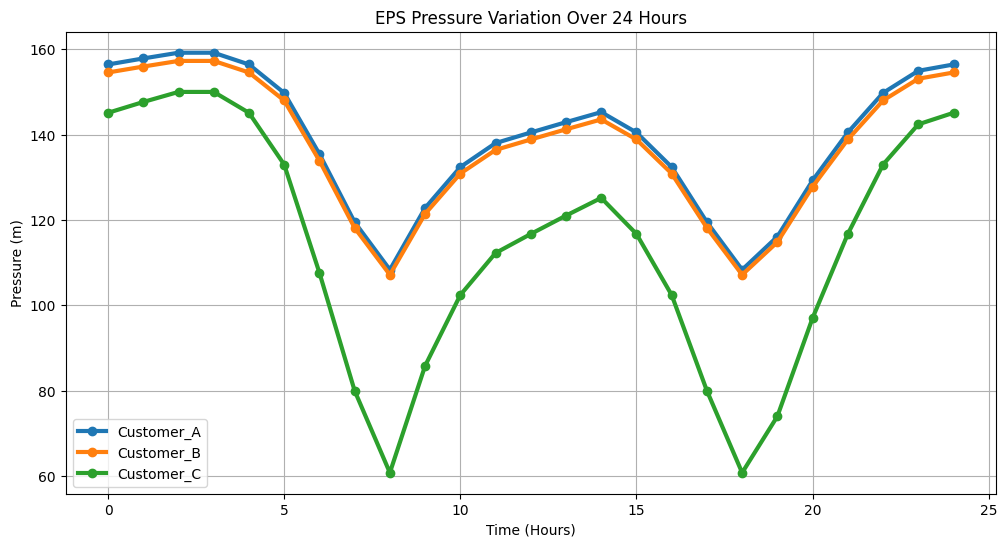

In [9]:
plt.figure(figsize=(12,6))

pressure_nodes = [

    "Customer_A",
    "Customer_B",
    "Customer_C"

]

for node in pressure_nodes:

    plt.plot(

        time_hours,

        pressure[node],

        linewidth=3,

        marker="o",

        label=node

    )

plt.grid(True)

plt.xlabel("Time (Hours)")

plt.ylabel("Pressure (m)")

plt.title("EPS Pressure Variation Over 24 Hours")

plt.legend()

plt.show()

# Pressure Variation During Extended Period Simulation

## Objective

Evaluate how customer pressure changes over a 24-hour operating cycle under varying water demand.

## Why?

Water demand changes throughout the day. As demand increases, more water flows through the network, increasing friction losses and reducing the available pressure at customer nodes.

## Observation

Pressure follows the daily demand pattern.

- Highest pressure occurs during low-demand periods (night).
- Lowest pressure occurs during morning and evening demand peaks.
- Customer_C experiences the largest pressure variation because it is located furthest from the pump and is supplied through the highest-resistance branch.

## Engineering Conclusion

The pressure profile confirms that the hydraulic model responds correctly to time-varying demand. The Extended Period Simulation successfully captures daily pressure fluctuations that occur in real water distribution systems.

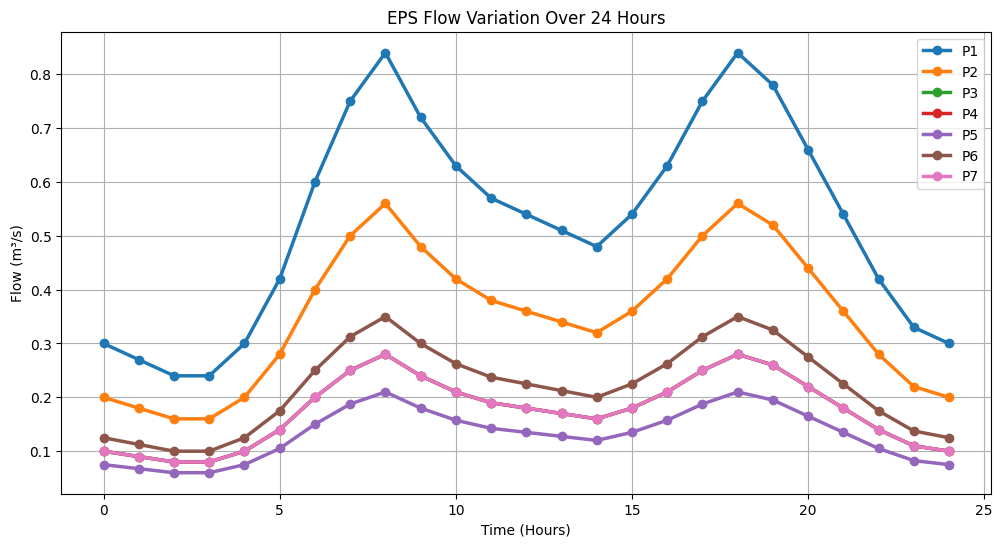

In [ ]:
plt.figure(figsize=(12,6))

flow_pipes = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7"
]

for pipe in flow_pipes:

    plt.plot(

        time_hours,

        flow[pipe],

        linewidth=2.5,

        marker="o",

        label=pipe

    )

plt.grid(True)

plt.xlabel("Time (Hours)")

plt.ylabel("Flow (m^3/s)")

plt.title("EPS Flow Variation Over 24 Hours")

plt.legend()

plt.show()

# Flow Variation During Extended Period Simulation

## Objective

Evaluate how pipe flow changes over a 24-hour operating cycle under varying customer demand.

## Why?

As customer demand changes throughout the day, the amount of water transported through each pipe also changes. Pipes closer to the water source carry the combined demand of downstream consumers and therefore experience the largest flow variations.

## Observation

- Flow increases during the morning and evening demand peaks.
- Flow decreases during low-demand periods at night.
- Pipe P1 carries the highest flow because it supplies the entire network.
- Downstream branch pipes carry only the demand of their connected customers.

## Engineering Conclusion

The flow variation follows the assigned daily demand pattern and confirms that the hydraulic model correctly redistributes flow throughout the network during an Extended Period Simulation.

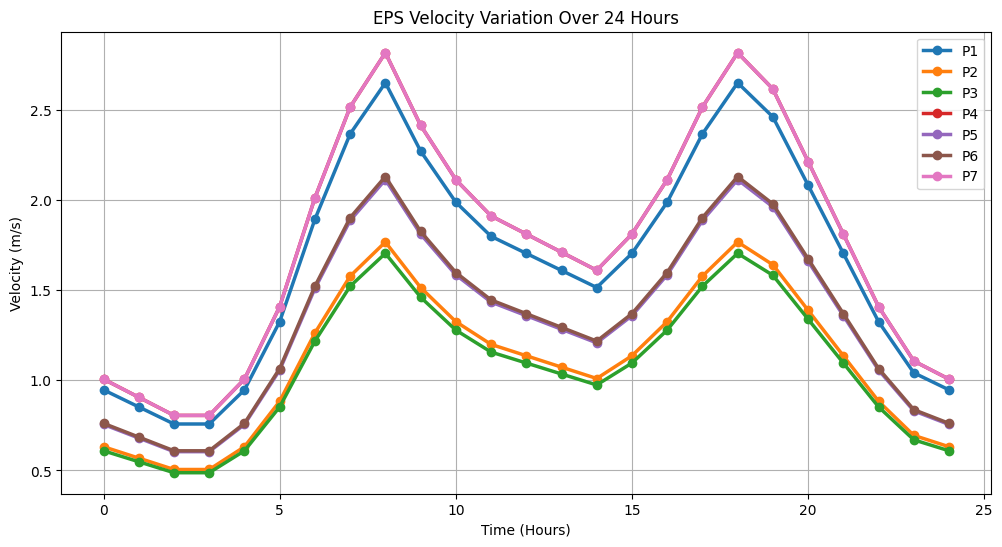

In [11]:
plt.figure(figsize=(12,6))

velocity_pipes = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7"
]

for pipe in velocity_pipes:

    plt.plot(
        time_hours,
        velocity[pipe],
        linewidth=2.5,
        marker="o",
        label=pipe
    )

plt.grid(True)

plt.xlabel("Time (Hours)")
plt.ylabel("Velocity (m/s)")
plt.title("EPS Velocity Variation Over 24 Hours")

plt.legend()

plt.show()

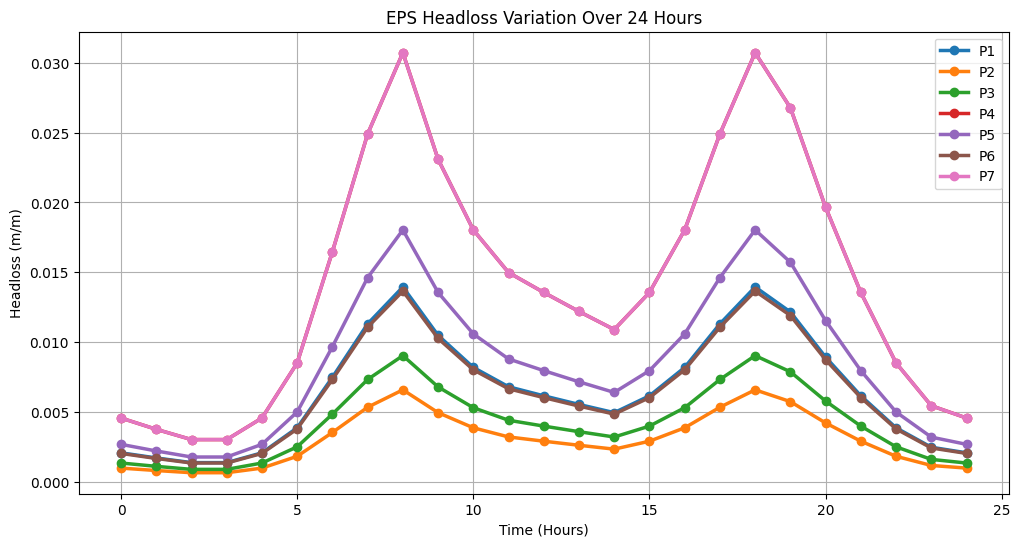

In [12]:
plt.figure(figsize=(12,6))

headloss_pipes = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7"
]

for pipe in headloss_pipes:

    plt.plot(
        time_hours,
        headloss[pipe],
        linewidth=2.5,
        marker="o",
        label=pipe
    )

plt.grid(True)

plt.xlabel("Time (Hours)")
plt.ylabel("Headloss (m/m)")
plt.title("EPS Headloss Variation Over 24 Hours")

plt.legend()

plt.show()

# Headloss Variation During Extended Period Simulation

## Objective

Evaluate how frictional energy losses vary throughout a 24-hour operating cycle.

## Why?

Headloss represents the hydraulic energy lost due to friction as water flows through the pipeline. It depends primarily on flow rate, pipe diameter and pipe length.

According to the Hazen-Williams equation,

Headloss ∝ (Flow^1.852 × Length) / Diameter^4.87

## Observation

- Headloss increases during the morning and evening demand peaks.
- Headloss decreases during low-demand periods.
- Pipes P5 and P7 exhibit the highest headloss because they have the smallest diameter.
- Larger transmission pipes maintain relatively low headloss despite carrying higher flow.

## Engineering Conclusion

The headloss profile follows the expected hydraulic behaviour of the network. Increased customer demand increases flow and consequently increases friction losses throughout the pipeline system.